In [4]:
import glob
print(glob.glob("runs/detect/**/best.pt", recursive=True))


['runs/detect\\train20\\weights\\best.pt', 'runs/detect\\train21\\weights\\best.pt', 'runs/detect\\train22\\weights\\best.pt', 'runs/detect\\train30\\weights\\best.pt']


In [1]:
from ultralytics import YOLO
import time


print("\n🚀 Starting YOLOv8 Brain Tumor Detection Training...\n")
start_time = time.time()

# Load YOLOv8 model
print("Loading YOLOv8 model...")
model = YOLO("yolov8n.pt")  
print(" Model loaded successfully!\n")

# Debug: Check Dataset Path
data_yaml_path = r"C:\Users\jayve\Downloads\BrainTumor\BrainTumorYolov8\data.yaml"
print(f"Using dataset configuration from: {data_yaml_path}")

# Start Training
print("\nTraining YOLOv8 model...")

# Train with per-epoch logging
results = model.train(
    data=data_yaml_path,  
    epochs=50,
    imgsz=640,
    batch=4,
    device="cuda",
    verbose=True  
)

print("Training Completed Successfully!\n")

# Print Per-Epoch Training Metrics
print("\nTraining Progress per Epoch:")
try:
    for epoch_idx, log in enumerate(results.metrics):  
        train_loss = log['train/loss']
        train_precision = log.get('metrics/precision(B)', "N/A")  # Some versions may use 'metrics/precision'

        print(f" Epoch {epoch_idx + 1}/{len(results.metrics)}")
        print(f"    Train Loss: {train_loss:.4f}")  
        print(f"    Train Accuracy (Precision): {train_precision}")
except Exception as e:
    print(f" Error retrieving epoch-wise training metrics: {e}")

# Final Training Metrics
print("\n Final Training Metrics:")
try:
    final_train_loss = results.metrics[-1]['train/loss']
    final_train_precision = results.metrics[-1].get('metrics/precision(B)', "N/A")

    print(f" Final Train Loss: {final_train_loss:.4f}")  
    print(f" Final Train Accuracy (Precision): {final_train_precision}")  
except Exception as e:
    print(f" Error retrieving final training metrics: {e}")

# Start Validation
print("\n  Running model validation...")
val_results = model.val()
print("Validation Completed Successfully!\n")

# Print Validation Metrics
print("\n Validation Metrics:")
try:
    val_loss = val_results.metrics['val/loss']
    val_precision = val_results.metrics.get('metrics/precision(B)', "N/A")
    val_recall = val_results.metrics.get('metrics/recall(B)', "N/A")
    val_map50 = val_results.metrics.get('metrics/mAP_50', "N/A")
    val_map50_95 = val_results.metrics.get('metrics/mAP_50-95', "N/A")

    print(f" Validation Loss: {val_loss:.4f}")
    print(f" Validation Accuracy (Precision): {val_precision}")
    print(f" Validation Recall: {val_recall}")
    print(f" Validation mAP@50: {val_map50}")
    print(f" Validation mAP@50-95: {val_map50_95}")
except Exception as e:
    print(f" Error retrieving validation metrics: {e}")

# End Script
end_time = time.time()
elapsed_time = end_time - start_time
print(f"\n Training & Validation Completed in {elapsed_time:.2f} seconds.\n")



🚀 Starting YOLOv8 Brain Tumor Detection Training...

🔄 Loading YOLOv8 model...
✅ Model loaded successfully!

📂 Using dataset configuration from: C:\Users\jayve\Downloads\BrainTumor\BrainTumorYolov8\data.yaml

🛠️  Training YOLOv8 model...
Ultralytics 8.3.94  Python-3.12.9 torch-2.6.0+cu118 CUDA:0 (NVIDIA GeForce RTX 2050, 4096MiB)
engine\trainer: task=detect, mode=train, model=yolov8n.pt, data=C:\Users\jayve\Downloads\BrainTumor\BrainTumorYolov8\data.yaml, epochs=50, time=None, patience=100, batch=4, imgsz=640, save=True, save_period=-1, cache=False, device=cuda, workers=8, project=None, name=train30, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=Fa

train: Scanning C:\Users\jayve\Downloads\BrainTumor\BrainTumorYolov8\train\labels.cache... 2144 images, 0 backgrounds, 

WARNING  Box and segment counts should be equal, but got len(segments) = 2143, len(boxes) = 2144. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.


albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


C:\Users\jayve\anaconda3\envs\Brain_Tumor\Lib\site-packages\albumentations\check_version.py:107: UserWarning: Error fetching version info <urlopen error [Errno 11001] getaddrinfo failed>
  data = fetch_version_info()
val: Scanning C:\Users\jayve\Downloads\BrainTumor\BrainTumorYolov8\valid\labels.cache... 612 images, 0 backgrounds, 0 c


...


50 epochs completed in 1.491 hours.
Optimizer stripped from runs\detect\train30\weights\last.pt, 6.2MB
Optimizer stripped from runs\detect\train30\weights\best.pt, 6.2MB

Validating runs\detect\train30\weights\best.pt...
Ultralytics 8.3.94  Python-3.12.9 torch-2.6.0+cu118 CUDA:0 (NVIDIA GeForce RTX 2050, 4096MiB)
Model summary (fused): 72 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 77/77 [00:10


                   all        612        612      0.885      0.852      0.909        0.7
                glioma        285        285      0.838      0.708      0.798      0.537
            meningioma        142        142      0.936      0.934      0.974      0.821
             pituitary        185        185       0.88      0.914      0.955      0.741
Speed: 0.5ms preprocess, 4.9ms inference, 0.0ms loss, 2.6ms postprocess per image
Results saved to runs\detect\train30
✅ Training Completed Successfully!


📊 Training Progress per Epoch:
❌ Error retrieving epoch-wise training metrics: 'DetMetrics' object has no attribute 'metrics'. See valid attributes below.

    Utility class for computing detection metrics such as precision, recall, and mean average precision (mAP).

    Attributes:
        save_dir (Path): A path to the directory where the output plots will be saved.
        plot (bool): A flag that indicates whether to plot precision-recall curves for each class.
        names (dic

val: Scanning C:\Users\jayve\Downloads\BrainTumor\BrainTumorYolov8\valid\labels.cache... 612 images, 0 backgrounds, 0 c
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 153/153 [00:


                   all        612        612      0.886      0.854      0.909      0.701
                glioma        285        285      0.835      0.708      0.798      0.537
            meningioma        142        142      0.943       0.94      0.975      0.824
             pituitary        185        185       0.88      0.913      0.955      0.742
Speed: 0.6ms preprocess, 8.1ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to runs\detect\train302
✅ Validation Completed Successfully!


✅ Validation Metrics:
❌ Error retrieving validation metrics: 'DetMetrics' object has no attribute 'metrics'. See valid attributes below.

    Utility class for computing detection metrics such as precision, recall, and mean average precision (mAP).

    Attributes:
        save_dir (Path): A path to the directory where the output plots will be saved.
        plot (bool): A flag that indicates whether to plot precision-recall curves for each class.
        names (dict): A dictionar

In [7]:
with open("runs/detect/train30/results.csv") as f:
    print(f.read())


epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
1,110.576,1.3727,3.42098,1.41991,0.59067,0.5046,0.53303,0.33423,1.39655,2.34238,1.54849,0.000475445,0.000475445,0.000475445
2,203.256,1.4016,2.55663,1.45475,0.57462,0.47215,0.48688,0.32292,1.34372,2.0485,1.477,0.000932933,0.000932933,0.000932933
3,299.154,1.4224,2.15794,1.50662,0.54309,0.57025,0.58566,0.39542,1.31902,1.81939,1.49334,0.00137156,0.00137156,0.00137156
4,393.502,1.39073,1.94602,1.44965,0.57142,0.61228,0.62843,0.42711,1.33227,1.79778,1.54098,0.00134412,0.00134412,0.00134412
5,487.767,1.34426,1.80793,1.44515,0.73601,0.65662,0.71732,0.47576,1.22538,1.62887,1.35709,0.00131582,0.00131582,0.00131582
6,582.342,1.29191,1.65259,1.40133,0.71567,0.64691,0.707,0.4833,1.25138,1.54701,1.42207,0.00128753,0.00128753,0.00128753
7,676.991,1.29407,1.58199,1.40581,0.77752,0.69348,0.75224,0.5273,1.20986,1

In [ ]:
from ultralytics import YOLO

# Load the trained YOLOv8 model
print(" Loading trained YOLOv8 model...")
model_path = "runs/detect/train30/weights/best.pt"  # Update with the best model path
model = YOLO(model_path)
print(" Model loaded successfully from", model_path)

# Path to dataset YAML file
data_yaml_path = r"C:\Users\jayve\Downloads\BrainTumor\BrainTumorYolov8\data.yaml"
print(f" Using dataset configuration from: {data_yaml_path}")

# Run evaluation on the test set
print("\n Evaluating the model on the test dataset...")
try:
    test_results = model.val(data=data_yaml_path, split="test")

    # Print Test Metrics
    print("\n Test Set Performance Metrics:")
    print(f"🔹 Test Loss: {test_results.box.loss:.4f}")
    print(f"🔹 Test Accuracy (Precision): {test_results.box.metrics['precision']:.4f}")
    print(f"🔹 Test Recall: {test_results.box.metrics['recall']:.4f}")
    print(f"🔹 Test mAP@50: {test_results.box.map50:.4f}")
    print(f"🔹 Test mAP@50-95: {test_results.box.map:.4f}")
    
except Exception as e:
    print(f" Error during evaluation: {e}")

print("\n Test Evaluation Completed!\n")


🔄 Loading trained YOLOv8 model...
✅ Model loaded successfully from runs/detect/train30/weights/best.pt
📂 Using dataset configuration from: C:\Users\jayve\Downloads\BrainTumor\BrainTumorYolov8\data.yaml

🛠️ Evaluating the model on the test dataset...
Ultralytics 8.3.94  Python-3.12.9 torch-2.6.0+cu118 CUDA:0 (NVIDIA GeForce RTX 2050, 4096MiB)
Model summary (fused): 72 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs


val: Scanning C:\Users\jayve\Downloads\BrainTumor\BrainTumorYolov8\test\labels... 308 images, 0 backgrounds, 0 corrupt:


val: New cache created: C:\Users\jayve\Downloads\BrainTumor\BrainTumorYolov8\test\labels.cache


🔄 Loading trained YOLOv8 model...
✅ Model loaded successfully!


0: 640x640 1 pituitary, 111.8ms
Speed: 9.2ms preprocess, 111.8ms inference, 3.7ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 pituitary, 70.9ms
Speed: 10.5ms preprocess, 70.9ms inference, 3.0ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 pituitary, 18.8ms
Speed: 4.5ms preprocess, 18.8ms inference, 3.5ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 pituitary, 15.6ms
Speed: 4.2ms preprocess, 15.6ms inference, 2.9ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 meningioma, 19.2ms
Speed: 4.8ms preprocess, 19.2ms inference, 3.6ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 glioma, 19.6ms
Speed: 4.2ms preprocess, 19.6ms inference, 3.7ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 21.1ms
Speed: 5.5ms preprocess, 21.1ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections),

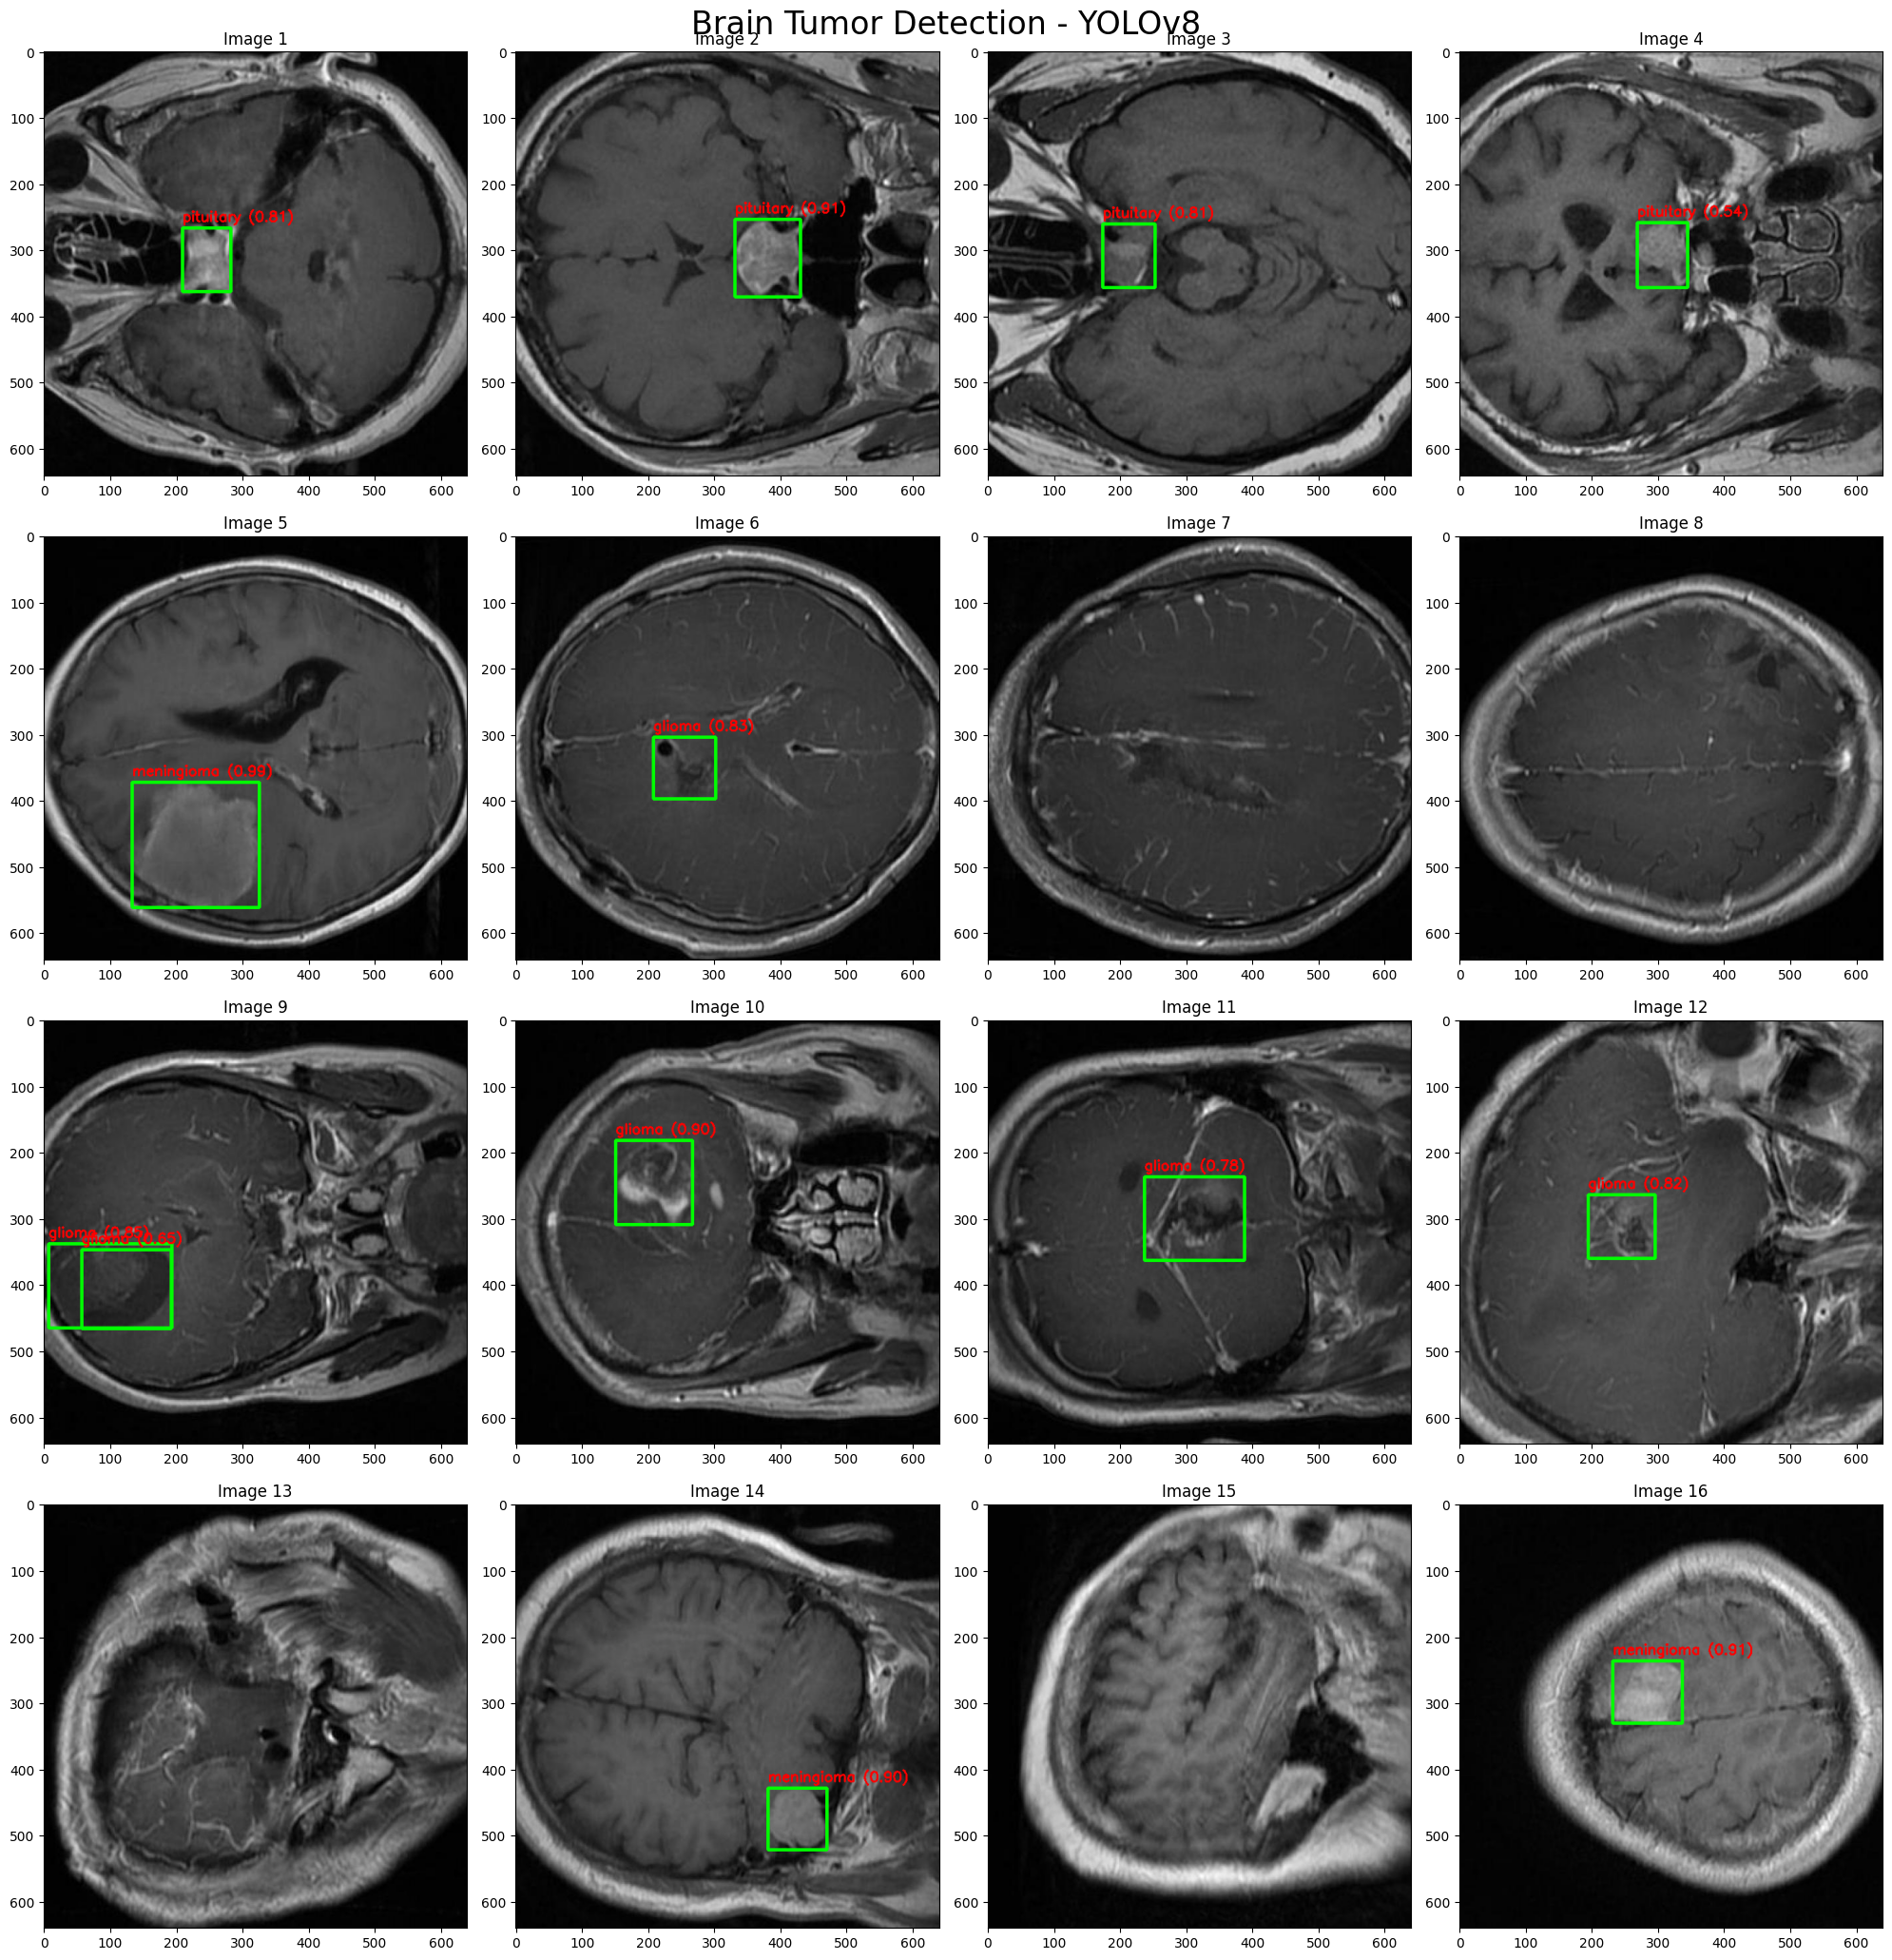

In [15]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Load the trained YOLOv8 model
print(" Loading trained YOLOv8 model...")
model = YOLO("runs/detect/train30/weights/best.pt")  # Update with correct path
print(" Model loaded successfully!\n")

# Path to test images
dataset_path = r"C:\Users\jayve\Downloads\BrainTumor\BrainTumorYolov8"
test_images_path = os.path.join(dataset_path, 'test', 'images')

# List all JPG images in the directory
image_files = [file for file in os.listdir(test_images_path) if file.endswith('.jpg')]

# Ensure images exist
if len(image_files) == 0:
    print("⚠ No test images found in the directory!")
    exit()

# Select up to 16 images for visualization
num_images = len(image_files)
step_size = max(1, num_images // 16)
selected_images = [image_files[i] for i in range(0, num_images, step_size)][:16]

# Create subplots for visualization
fig, axes = plt.subplots(4, 4, figsize=(20, 21))
fig.suptitle('Brain Tumor Detection - YOLOv8', fontsize=24)

# Class names dictionary
class_names = model.names  # Class index to name mapping
if not class_names:
    print("⚠ Warning: Model class names not found!")

for i, ax in enumerate(axes.flatten()):
    if i < len(selected_images):
        image_path = os.path.join(test_images_path, selected_images[i])
        image = cv2.imread(image_path)

        if image is None:
            print(f"⚠ Warning: Unable to load {image_path}. Skipping...")
            continue

        # Convert BGR to RGB for correct display
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Run YOLOv8 inference
        results = model.predict(image_rgb, imgsz=640, conf=0.5)[0]

        # Extract detections
        if len(results.boxes) > 0:  #  Check if there are detections
            for box in results.boxes.data:  # Access tensor data
                x1, y1, x2, y2 = map(int, box[:4])  # Bounding box coordinates
                confidence = float(box[4])  # Confidence score
                class_id = int(box[5])  # Class index

                label = f"{class_names.get(class_id, 'Unknown')} ({confidence:.2f})"
                
                # Draw bounding box and label
                cv2.rectangle(image_rgb, (x1, y1), (x2, y2), (0, 255, 0), 3)
                cv2.putText(image_rgb, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)

        # Display the image
        ax.imshow(image_rgb)
        ax.set_title(f"Image {i+1}")
    else:
        ax.axis('off')  # Hide unused subplots

plt.tight_layout()
plt.show()


✅ Model loaded successfully!

0: 640x640 1 glioma, 23.4ms
1: 640x640 1 glioma, 23.4ms
2: 640x640 1 glioma, 23.4ms
3: 640x640 1 glioma, 23.4ms
4: 640x640 1 glioma, 23.4ms
5: 640x640 2 gliomas, 23.4ms
6: 640x640 1 glioma, 23.4ms
7: 640x640 1 glioma, 23.4ms
8: 640x640 1 glioma, 23.4ms
9: 640x640 1 pituitary, 23.4ms
10: 640x640 1 pituitary, 23.4ms
11: 640x640 1 pituitary, 23.4ms
12: 640x640 1 pituitary, 23.4ms
13: 640x640 (no detections), 23.4ms
14: 640x640 1 pituitary, 23.4ms
Speed: 10.4ms preprocess, 23.4ms inference, 3.1ms postprocess per image at shape (1, 3, 640, 640)


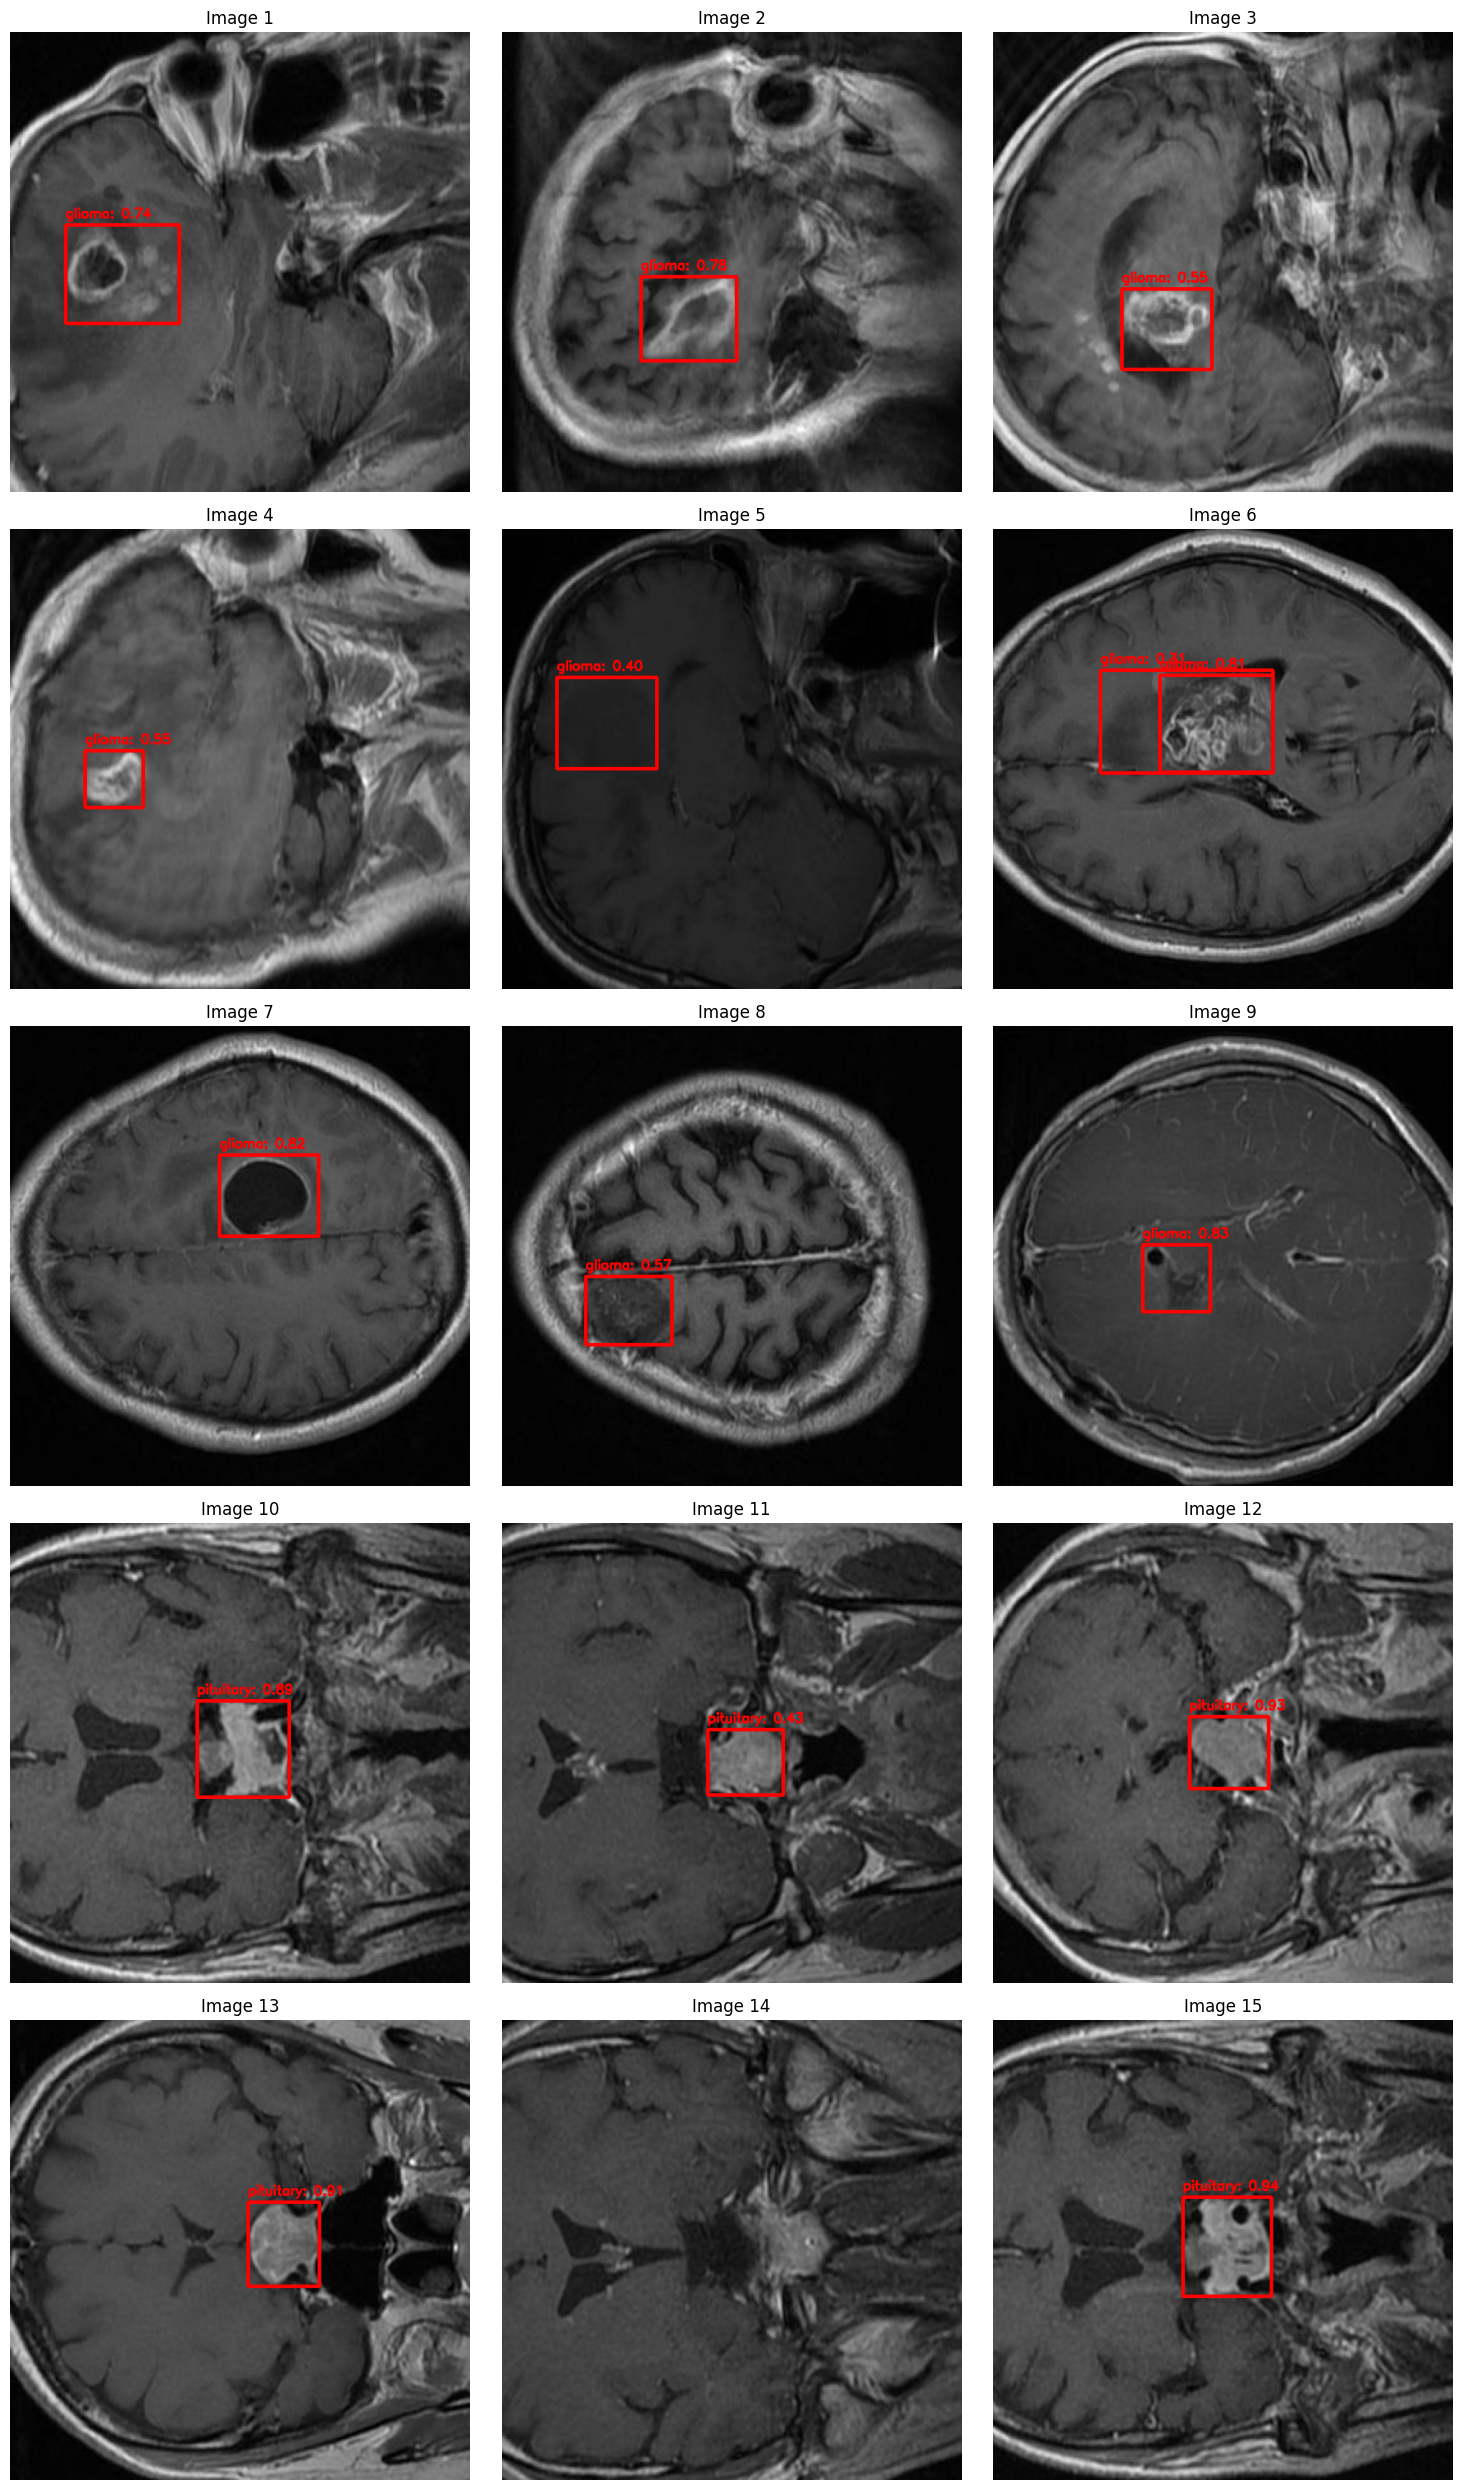

In [14]:
import torch
import cv2
import matplotlib.pyplot as plt
import math
from ultralytics import YOLO

# Load the trained YOLOv8 model
model_path = "runs/detect/train30/weights/best.pt"  # Update if needed
model = YOLO(model_path)
print("Model loaded successfully!")

# Provide test image paths (Change these to your actual test images)
test_images = [
    r"C:\Users\jayve\Downloads\BrainTumor\BrainTumorYolov11\test\images\900_jpg.rf.70fdbdeca5b71e51595bd918985f600e.jpg",
    r"C:\Users\jayve\Downloads\BrainTumor\BrainTumorYolov11\test\images\847_jpg.rf.2dc346a6966f354e814f5a44aad76850.jpg",
    r"C:\Users\jayve\Downloads\BrainTumor\BrainTumorYolov11\test\images\851_jpg.rf.2eca43fe592d92eb4bc1a7afacbd0072.jpg",
    r"C:\Users\jayve\Downloads\BrainTumor\BrainTumorYolov11\test\images\880_jpg.rf.820fdd0175c897a5334c8b4a9e5a65bc.jpg",
    r"C:\Users\jayve\Downloads\BrainTumor\BrainTumorYolov11\test\images\882_jpg.rf.ffc07ad6a95db14d77d6280f023d2a33.jpg",
    r"C:\Users\jayve\Downloads\BrainTumor\BrainTumorYolov11\test\images\1864_jpg.rf.acb2bda42df505957e9b381fed5d8a6b.jpg",
    r"C:\Users\jayve\Downloads\BrainTumor\BrainTumorYolov11\test\images\1867_jpg.rf.6463f5e7fc2480ed5a7a55d68f58c533.jpg",
    r"C:\Users\jayve\Downloads\BrainTumor\BrainTumorYolov11\test\images\1884_jpg.rf.e4fe0c8cb99a3aeeed39ea7cec0b0948.jpg",
    r"C:\Users\jayve\Downloads\BrainTumor\BrainTumorYolov11\test\images\1885_jpg.rf.fcf3a657b0b2fc6c2e9f9c48612f4d08.jpg",
    r"C:\Users\jayve\Downloads\BrainTumor\BrainTumorYolov11\test\images\1091_jpg.rf.5308c91865f1e3a19de6936a0d295339.jpg",
    r"C:\Users\jayve\Downloads\BrainTumor\BrainTumorYolov11\test\images\1122_jpg.rf.e5b7d9dd059312db750f9a9574ab9cf2.jpg",
    r"C:\Users\jayve\Downloads\BrainTumor\BrainTumorYolov11\test\images\1125_jpg.rf.82a5cbb71e2dc11bb6227afeaf7eada8.jpg",
    r"C:\Users\jayve\Downloads\BrainTumor\BrainTumorYolov11\test\images\1157_jpg.rf.034c9ffcd15fd9a89a3af651dabfeb67.jpg",
    r"C:\Users\jayve\Downloads\BrainTumor\BrainTumorYolov11\test\images\1087_jpg.rf.11aea0eb9fc21920ffd9adc7f86be8a5.jpg",
    r"C:\Users\jayve\Downloads\BrainTumor\BrainTumorYolov11\test\images\1090_jpg.rf.49e77ec069279939ebd855ac1f14912c.jpg"

]

# Define a function to visualize results in a grid
def visualize_detections_grid(image_paths, results, cols=3):
    num_images = len(image_paths)
    rows = math.ceil(num_images / cols)  # Calculate the number of rows
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = axes.flatten()  # Flatten in case of single row
    
    for i, (ax, image_path, result) in enumerate(zip(axes, image_paths, results)):
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB

        for box in result.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])  # Get bounding box
            conf = box.conf[0].item()  # Confidence score
            class_id = int(box.cls[0].item())  # Class ID
            label = f"{model.names[class_id]}: {conf:.2f}"

            cv2.rectangle(image, (x1, y1), (x2, y2), (255, 0, 0), 3)
            cv2.putText(image, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

        ax.imshow(image)
        ax.axis("off")
        ax.set_title(f"Image {i+1}")
    
    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

# Run inference & visualize results
results = model(test_images)  # Run inference on all images
visualize_detections_grid(test_images, results, cols=3)


In [2]:
from ultralytics import YOLO
model_path = "runs/detect/train30/weights/best.pt"  # Update if needed
model = YOLO(model_path)
print("Model loaded successfully!")

Model loaded successfully!


In [5]:
print(model.model)
input_size = model.model.args['imgsz']
print("Input size:", input_size)
model.info()

DetectionModel(
  (model): Sequential(
    (0): Conv(
      (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (2): C2f(
      (cv1): Conv(
        (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
    

(129, 3011433, 0, 8.1963008)